# Iranian Telecom Churn - Complete Pipeline
This notebook contains the complete pipeline for the Iranian Telecom Churn prediction model, including:
- Data preprocessing
- Dataset creation
- Model definition
- Training with StepLR scheduler

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import StepLR
from torchmetrics import F1Score, Accuracy, Recall, Precision
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split
import os
from pathlib import Path

# Set paths
BASE_PATH = Path.cwd()
while not (BASE_PATH / "data").exists() and BASE_PATH != BASE_PATH.parent:
    BASE_PATH = BASE_PATH.parent
DATA_RAW = BASE_PATH / "data" / "raw" / "Customer Churn.csv"
DATA_PROCESSED = BASE_PATH / "data" / "processed"
MODEL_PATH = BASE_PATH / "models" / "Iranian_Telecom_Churn_model.pth"

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Preprocessing
Load and preprocess the raw data, applying appropriate transformations to each feature type.

Original data shape: (3150, 14)
Columns: ['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']


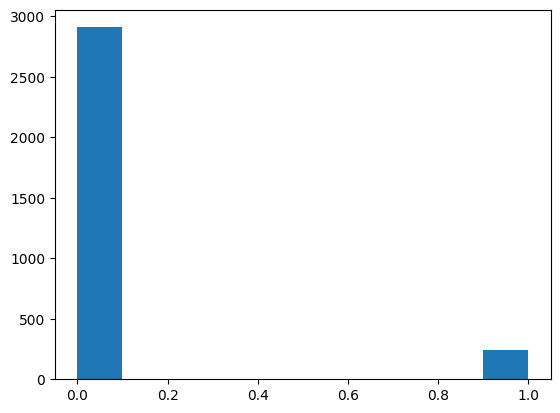

In [3]:
# Load raw data
import matplotlib.pyplot as plt
data = pd.read_csv(DATA_RAW)
print(f"Original data shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")

plt.hist(data['Complains'])
plt.show()

In [4]:
# Define feature groups based on their distributions
minmax = ['Tariff Plan', 'Status', 'Complains']
standard = ['Age Group', 'Age']
powerT = ['Call  Failure', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 
          'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Customer Value']

# Initialize scalers
st = StandardScaler()
pt = PowerTransformer()
mm = MinMaxScaler()

# Split features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-validation-test split (70-15-15)
X_train, X_sample, y_train, y_sample = train_test_split(X, y, test_size=0.3, stratify=y, random_state=222)
X_test, X_val, y_test, y_val = train_test_split(X_sample, y_sample, test_size=0.5, stratify=y_sample, random_state=22)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Training set: (2205, 13)
Validation set: (473, 13)
Test set: (472, 13)


In [5]:
# Transform functions
def transform_tr(data, minmax_cols, mm, standard_cols, st, powerT_cols, pt):
    """Transform training data - fits and transforms."""
    data[minmax_cols] = mm.fit_transform(data[minmax_cols])
    data[standard_cols] = st.fit_transform(data[standard_cols])
    data[powerT_cols] = pt.fit_transform(data[powerT_cols])
    return data

def transform_tv(data, minmax_cols, mm, standard_cols, st, powerT_cols, pt):
    """Transform validation/test data - only transforms using fitted scalers."""
    data[minmax_cols] = mm.transform(data[minmax_cols])
    data[standard_cols] = st.transform(data[standard_cols])
    data[powerT_cols] = pt.transform(data[powerT_cols])
    return data

# Transform and save training data
data_train = transform_tr(X_train.copy(), minmax, mm, standard, st, powerT, pt)
data_train['Churn'] = y_train
data_train.to_csv(os.path.join(DATA_PROCESSED, 'data_train.csv'), index=False)

# Transform and save test data
data_test = transform_tv(X_test.copy(), minmax, mm, standard, st, powerT, pt)
data_test['Churn'] = y_test
data_test.to_csv(os.path.join(DATA_PROCESSED, 'data_test.csv'), index=False)

# Transform and save validation data
data_validation = transform_tv(X_val.copy(), minmax, mm, standard, st, powerT, pt)
data_validation['Churn'] = y_val
data_validation.to_csv(os.path.join(DATA_PROCESSED, 'data_validation.csv'), index=False)

print("Data preprocessing complete! Files saved to processed folder.")

Data preprocessing complete! Files saved to processed folder.


## 2. Dataset Class
Define the PyTorch Dataset class for loading the preprocessed data.

In [8]:
# Dataset class
class ChurnDataSet(Dataset):
    def __init__(self, data):
        super(ChurnDataSet, self).__init__()
        self.data = data
        self.data = torch.from_numpy(self.data.to_numpy()).float()
        
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x = self.data[idx, :-1]
        y = self.data[idx, -1]
        return x, y

# Create datasets
train_set = ChurnDataSet(pd.read_csv(os.path.join(DATA_PROCESSED, 'data_train.csv')))
test_set = ChurnDataSet(pd.read_csv(os.path.join(DATA_PROCESSED, 'data_test.csv')))
val_set = ChurnDataSet(pd.read_csv(os.path.join(DATA_PROCESSED, 'data_validation.csv')))

# Create data loaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=150, shuffle=False)
val_loader = DataLoader(val_set, batch_size=150, shuffle=False)

print(f"Train samples: {len(train_set)}")
print(f"Validation samples: {len(val_set)}")
print(f"Test samples: {len(test_set)}")

Train samples: 2205
Validation samples: 473
Test samples: 472


## 3. Model Definition
Define the neural network architecture for churn prediction.

In [7]:
# Model definition
class ChurnModule(nn.Module):
    def __init__(self):
        super(ChurnModule, self).__init__()
        self.layer1 = nn.Linear(13, 30)
        self.layer2 = nn.Linear(30, 1024)
        self.bn1 = nn.BatchNorm1d(1024)

        self.actv1 = nn.Hardswish()
        self.layer3 = nn.Linear(1024, 5)
        self.bn2 = nn.BatchNorm1d(5)
        self.layer4 = nn.Linear(5, 1024)

        self.actv2 = nn.Hardswish()
        self.layer5 = nn.Linear(1024, 1)
        self.final = nn.Sigmoid()
        
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.bn1(x)

        x = self.actv1(x)
        x = self.layer3(x)
        x = self.bn2(x)
        x = self.layer4(x)
        
        x = self.actv2(x)
        x = self.layer5(x)
        score = self.final(x)
        return score

# Initialize model
model = ChurnModule()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

ChurnModule(
  (layer1): Linear(in_features=13, out_features=30, bias=True)
  (layer2): Linear(in_features=30, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actv1): Hardswish()
  (layer3): Linear(in_features=1024, out_features=5, bias=True)
  (bn2): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer4): Linear(in_features=5, out_features=1024, bias=True)
  (actv2): Hardswish()
  (layer5): Linear(in_features=1024, out_features=1, bias=True)
  (final): Sigmoid()
)

Total parameters: 46516


## 4. Training with StepLR Scheduler
Train the model with the StepLR scheduler that updates the learning rate with gamma=0.02 after every 7 epochs.

In [12]:
# Initialize metrics
f1_score = F1Score(task='binary')
accuracy_score = Accuracy(task='binary')
recall_score = Recall(task='binary')
precision_score = Precision(task='binary')

f1_score_val = F1Score(task='binary')
accuracy_score_val = Accuracy(task='binary')
recall_score_val = Recall(task='binary')
precision_score_val = Precision(task='binary')

# Initialize model, loss function, and optimizer
model = ChurnModule()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

# StepLR scheduler: gamma=0.1, step_size=20 (updates LR after every 7 epochs)
scheduler = StepLR(optimizer, step_size=500, gamma=0.25)

print("Training configuration:")
print(f"  - Initial learning rate: 0.001")
print(f"  - Scheduler: StepLR with gamma=0.1, step_size=20")
print(f"  - Loss function: BCELoss")
print(f"  - Optimizer: SGD")

Training configuration:
  - Initial learning rate: 0.001
  - Scheduler: StepLR with gamma=0.1, step_size=20
  - Loss function: BCELoss
  - Optimizer: SGD


In [13]:
# Training loop
num_epochs = 15000

for epoch in range(1, num_epochs + 1):
    # Training phase
    model.train()
    running_loss = 0.0
    
    # Reset metrics
    f1_score.reset()
    accuracy_score.reset()
    recall_score.reset()
    precision_score.reset()
    
    for features, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(features)
        
        loss = criterion(outputs.squeeze(1), labels)
        f1_score.update(outputs.squeeze(1), labels)
        accuracy_score.update(outputs.squeeze(1), labels)
        recall_score.update(outputs.squeeze(1), labels)
        precision_score.update(outputs.squeeze(1), labels)
        
        running_loss += loss.item()
        loss.backward()
        optimizer.step()
    
    # Calculate training metrics
    train_accuracy = accuracy_score.compute().item()
    train_recall = recall_score.compute().item()
    train_precision = precision_score.compute().item()
    train_f1 = f1_score.compute().item()
    train_loss = running_loss / len(train_loader)
    
    # Validation phase
    model.eval()
    val_running_loss = 0.0
    
    # Reset validation metrics
    f1_score_val.reset()
    accuracy_score_val.reset()
    recall_score_val.reset()
    precision_score_val.reset()
    
    with torch.no_grad():
        for features, labels in val_loader:
            outputs = model(features)
            loss = criterion(outputs.squeeze(1), labels)
            f1_score_val.update(outputs.squeeze(1), labels)
            accuracy_score_val.update(outputs.squeeze(1), labels)
            recall_score_val.update(outputs.squeeze(1), labels)
            precision_score_val.update(outputs.squeeze(1), labels)
            val_running_loss += loss.item()
    
    # Calculate validation metrics
    val_accuracy = accuracy_score_val.compute().item()
    val_recall = recall_score_val.compute().item()
    val_precision = precision_score_val.compute().item()
    val_f1 = f1_score_val.compute().item()
    val_loss = val_running_loss / len(val_loader)
    
    # Print epoch results
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:2d}/{num_epochs} | LR: {current_lr:.6f}")
    print(f"  Train -> Loss: {train_loss:.4f} | Acc: {train_accuracy*100:.2f}% | F1: {train_f1*100:.2f}% | Recall: {train_recall*100:.2f}% | Precision: {train_precision*100:.2f}%")
    print(f"  Val   -> Loss: {val_loss:.4f} | Acc: {val_accuracy*100:.2f}% | F1: {val_f1*100:.2f}% | Recall: {val_recall*100:.2f}% | Precision: {val_precision*100:.2f}%")
    print("-" * 80)
    
    # Step the scheduler after each epoch
    scheduler.step()

print("\nTraining complete!")

Epoch  1/15000 | LR: 0.001000
  Train -> Loss: 0.6163 | Acc: 69.07% | F1: 37.77% | Recall: 59.65% | Precision: 27.64%
  Val   -> Loss: 0.5314 | Acc: 84.57% | F1: 42.52% | Recall: 36.49% | Precision: 50.94%
--------------------------------------------------------------------------------
Epoch  2/15000 | LR: 0.001000
  Train -> Loss: 0.4931 | Acc: 84.72% | F1: 19.95% | Recall: 12.10% | Precision: 56.76%
  Val   -> Loss: 0.4380 | Acc: 87.74% | F1: 39.58% | Recall: 25.68% | Precision: 86.36%
--------------------------------------------------------------------------------
Epoch  3/15000 | LR: 0.001000
  Train -> Loss: 0.4214 | Acc: 86.94% | F1: 42.86% | Recall: 31.12% | Precision: 68.79%
  Val   -> Loss: 0.3746 | Acc: 88.79% | F1: 48.54% | Recall: 33.78% | Precision: 86.21%
--------------------------------------------------------------------------------
Epoch  4/15000 | LR: 0.001000
  Train -> Loss: 0.3686 | Acc: 88.34% | F1: 53.36% | Recall: 42.36% | Precision: 72.06%
  Val   -> Loss: 0.32

In [14]:
# Save the trained model
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

Model saved to: C:\Users\Administrator\Documents\Data_Science__Projects\Iranian_Telecom_Churn\models\Iranian_Telecom_Churn_model.pth


## 5. Model Evaluation on Test Set
Evaluate the trained model on the held-out test set.

In [17]:
# Load the best model (optional - if you want to reload)
# model.load_state_dict(torch.load(MODEL_PATH))

# Test evaluation
model.eval()
test_f1_score = F1Score(task='binary')
test_accuracy_score = Accuracy(task='binary')
test_recall_score = Recall(task='binary')
test_precision_score = Precision(task='binary')

with torch.no_grad():
    for features, labels in test_loader:
        outputs = model(features)
        test_f1_score.update(outputs.squeeze(1), labels)
        test_accuracy_score.update(outputs.squeeze(1), labels)
        test_recall_score.update(outputs.squeeze(1), labels)
        test_precision_score.update(outputs.squeeze(1), labels)

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"Accuracy:  {test_accuracy_score.compute().item()*100:.2f}%")
print(f"F1 Score:  {test_f1_score.compute().item()*100:.2f}%")
print(f"Recall:    {test_recall_score.compute().item()*100:.2f}%")
print(f"Precision: {test_precision_score.compute().item()*100:.2f}%")
print("=" * 50)

TEST SET RESULTS
Accuracy:  96.61%
F1 Score:  89.47%
Recall:    91.89%
Precision: 87.18%


## 6. Load Trained Model
Load the saved model weights for inference without retraining.

In [9]:
# Load trained model
import torch.nn.init as init
class ChurnModule(nn.Module):
    def __init__(self):
        super(ChurnModule, self).__init__()
        self.layer1 = nn.Linear(13, 30)
        self.layer2 = nn.Linear(30, 1024)
        self.bn1 = nn.BatchNorm1d(1024)

        self.actv1 = nn.LeakyReLU(-0.1)
        self.layer3 = nn.Linear(1024, 50)
        self.bn2 = nn.BatchNorm1d(50)
        self.layer4 = nn.Linear(50, 1024)

        self.actv2 = nn.ReLU()
        self.layer5 = nn.Linear(1024, 1)
        self.final = nn.Sigmoid()
        
        init.kaiming_normal_(self.layer1.weight)
        init.kaiming_normal_(self.layer2.weight)
        init.kaiming_normal_(self.layer3.weight)
        init.kaiming_normal_(self.layer4.weight)
        init.kaiming_normal_(self.layer5.weight)
        
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.actv1(x)
        x = self.layer2(x)
        x = self.actv1(x)
        x = self.bn1(x)

        x = self.layer3(x)
        x = self.actv1(x)
        x = self.bn2(x)
        x = self.layer4(x)
        
        x = self.actv1(x)
        x = self.layer5(x)
        score = self.final(x)
        return score
    
model = ChurnModule()
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
print(f"Model loaded from: {MODEL_PATH}")

Model loaded from: c:\Users\Administrator\Documents\Data_Science__Projects\Iranian_Telecom_Churn\models\Iranian_Telecom_Churn_model.pth


## 7. ROC Curve and Confusion Matrix
Generate ROC curve and confusion matrix for model evaluation.

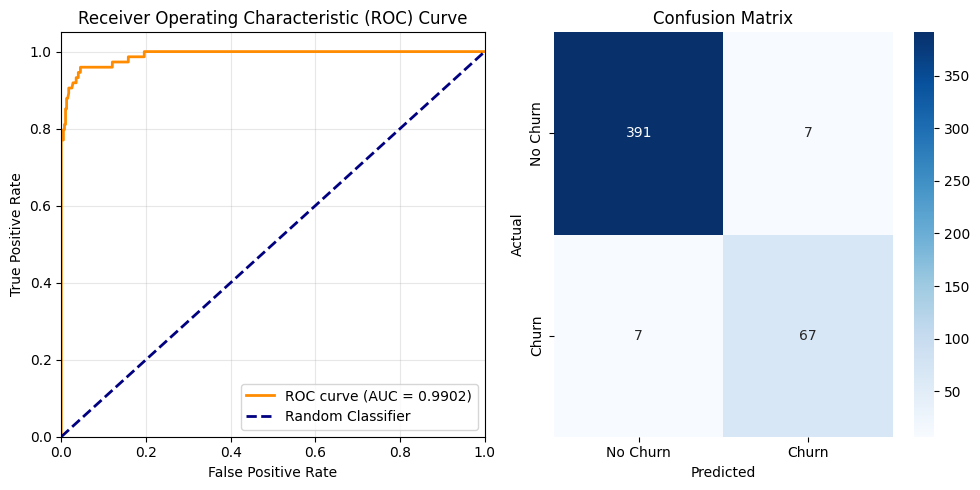


Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.98      0.98      0.98       398
       Churn       0.91      0.91      0.91        74

    accuracy                           0.97       472
   macro avg       0.94      0.94      0.94       472
weighted avg       0.97      0.97      0.97       472



In [11]:
# Import additional metrics
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions on test set
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for features, labels in test_loader:
        outputs = model(features)
        probs = outputs.squeeze(1).numpy()
        preds = (probs > 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Calculate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print("-" * 50)
print(classification_report(all_labels, all_preds, target_names=['No Churn', 'Churn']))